# Лабораторная работа F1 — Оценка спектра: окно, утечка и усреднение

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/biomenace/digital-signal-processing/blob/main/notebooks/f1.ipynb)

Ноутбук-спутник к интерактивной работе: **[открыть саму лабораторную](https://biomenace.github.io/digital-signal-processing/labs/f1.html)**.

**Что разбираем.** В E2 мы считали спектр и смотрели на пики. Но БПФ считает
спектр не «сигнала», а вырезанного из него куска длиной $L$ отсчётов.
Математически вырезание — это умножение на **окно** $w[n]$, и от формы окна
зависит, что мы увидим.

Три вещи, которые проверим в коде:

1. частота, попавшая точно в узел сетки $\Delta f = F_д/L$, не течёт вовсе,
   а попавшая ровно между узлами — течёт максимально;
2. окно Хэмминга давит боковые лепестки на десятки децибел, но расширяет
   главный пик — это обмен, а не бесплатное улучшение;
3. у шумоподобного сигнала (ЭМГ именно такой) одна периодограмма ничего не
   оценивает, и её надо усреднять по нескольким окнам — метод Уэлча.

In [1]:
# ЯЧЕЙКА 1 · Установка и импорты.
# Запусти один раз в начале работы и больше сюда не возвращайся.
# В Google Colab почти всё уже стоит, поэтому обычно ничего не скачивается.

import importlib.util
import subprocess
import sys


def ensure(packages):
    """Ставит только те пакеты, которых нет. packages: [(модуль, имя-для-pip)]."""
    missing = [pip for mod, pip in packages if not importlib.util.find_spec(mod)]
    if missing:
        print("Ставлю:", ", ".join(missing))
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing],
                       check=True)
    print("Готово. Python", sys.version.split()[0])


ensure([("numpy", "numpy"), ("scipy", "scipy"), ("matplotlib", "matplotlib")])

import numpy as np
import matplotlib
import matplotlib.pyplot as plt

%matplotlib inline
matplotlib.rcParams.update({
    "figure.figsize": (11, 4.5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.linewidth": 0.4,
    "axes.titlesize": 12,
    "font.size": 11,
})

Готово. Python 3.10.12


## Ячейка 2 · Сигналы, с которыми работаем

Три классических объекта спектрального анализа, каждый в ЭМГ-исполнении:

| Что это | Как выглядит спектр | Наш пример |
|---|---|---|
| периодическое колебание | отдельные линии | наводка сети 50 Гц и гармоники |
| одиночный импульс конечной энергии | гладкая плотность | один разряд MUAP |
| реализация случайного процесса | точного спектра нет, только оценка | сама ЭМГ |

In [2]:
# ЯЧЕЙКА · Синтетическая ЭМГ из отдельных разрядов.
# Дальше все сигналы в этой работе строятся этими четырьмя функциями.
#
# Мышца состоит из двигательных единиц — мотонейрон плюс все волокна, которыми
# он управляет. Каждая единица разряжается 8–20 раз в секунду, и каждый разряд
# даёт на электроде короткий двухфазный всплеск: MUAP, потенциал действия
# двигательной единицы. Поверхностный электрод складывает разряды многих
# единиц — получается «интерференционная» ЭМГ, шумоподобная на вид.

import numpy as np


def muap(fs, ms=10.0):
    """Форма одного разряда: двухфазный всплеск длиной ms миллисекунд.

    Берём производную гауссианы — простейшая форма с двумя фазами и нулевым
    средним, то есть без постоянной составляющей, как у настоящего MUAP.
    """
    half = max(2, round(ms / 1000 * fs / 2))
    t = np.arange(2 * half + 1) - half
    sigma = (2 * half + 1) / 6
    shape = -(t / sigma ** 2) * np.exp(-t ** 2 / (2 * sigma ** 2))
    return shape / np.abs(shape).max()


def synth_emg(n, fs, units=10, seed=0):
    """Интерференционная ЭМГ: сумма разрядов нескольких двигательных единиц.

    У каждой единицы своя частота разрядов и своя амплитуда, а интервалы между
    разрядами слегка гуляют — поэтому сумма и выглядит шумоподобной.
    Результат нормирован на единичное СКО.
    """
    rng = np.random.default_rng(seed)
    shape = muap(fs)
    x = np.zeros(n)
    for _ in range(units):
        rate = rng.uniform(8, 20)                 # разрядов в секунду
        amplitude = rng.uniform(0.5, 1.5)
        position = rng.uniform(0, fs / rate)
        while position < n - len(shape):
            start = int(round(position))
            x[start:start + len(shape)] += amplitude * shape
            position += (fs / rate) * rng.uniform(0.75, 1.25)
    x /= np.sqrt(np.mean(x ** 2)) or 1.0
    return x + 0.05 * rng.standard_normal(n)      # шум усилителя


def mains_hum(n, fs):
    """Наводка от электросети: 50 Гц плюс гармоники 100 и 150 Гц."""
    t = np.arange(n) / fs
    return (np.sin(2 * np.pi * 50 * t)
            + 0.35 * np.sin(2 * np.pi * 100 * t)
            + 0.15 * np.sin(2 * np.pi * 150 * t))


def median_frequency(freqs, psd, band=(20.0, 450.0)):
    """MDF: частота, ниже которой лежит половина мощности сигнала в полосе.

    Считается по спектру мощности, поэтому качество оценки спектра прямо
    определяет, насколько устойчиво получается MDF.
    """
    inside = (freqs >= band[0]) & (freqs <= band[1])
    cumulative = np.cumsum(psd[inside])
    return float(freqs[inside][np.searchsorted(cumulative, cumulative[-1] / 2)])


print("Готово: muap, synth_emg, mains_hum, median_frequency")

Готово: muap, synth_emg, mains_hum, median_frequency


## Ячейка 3 · Утечка спектра: куда девается энергия

БПФ считает, что кусок повторяется по кругу: он мысленно склеивает конец
куска с началом. Если на склейке не сходится — в сигнале появляется скачок,
которого не было, и БПФ честно раскладывает этот скачок по частотам.

Возьмём $F_д = 1000$ Гц и $L = 200$. Тогда шаг сетки ровно
$\Delta f = 1000/200 = 5$ Гц, и 50 Гц попадает точно в узел номер 10.

In [3]:
FS = 1000.0
L_TONE = 200
DF = FS / L_TONE

n = np.arange(L_TONE)
WINDOWS = {
    "прямоугольное": np.ones(L_TONE),
    "Хэмминга": 0.54 - 0.46 * np.cos(2 * np.pi * n / (L_TONE - 1)),
}


def tone_spectrum_db(f0, window):
    """Спектр одного тона в окне, в децибелах относительно собственного пика."""
    spectrum = np.abs(np.fft.rfft(np.sin(2 * np.pi * f0 * n / FS) * window))
    return 20 * np.log10(spectrum / spectrum.max() + 1e-12)


def sidelobe_level(db, guard=3):
    """Самый высокий боковой лепесток: максимум вне окрестности пика."""
    peak = int(np.argmax(db))
    mask = np.ones(len(db), bool)
    mask[max(0, peak - guard):peak + guard + 1] = False
    return db[mask].max()


freqs = np.fft.rfftfreq(L_TONE, d=1 / FS)
for f0 in (50.0, 47.5):
    k = f0 / DF
    print("тон %5.2f Гц → в окне %.2f периодов, k = f/Δf = %.2f  (%s)"
          % (f0, f0 * L_TONE / FS, k,
             "узел сетки" if abs(k - round(k)) < 1e-9 else "между узлами"))
    for name, window in WINDOWS.items():
        db = tone_spectrum_db(f0, window)
        print("      %-14s боковые лепестки до %6.1f дБ" % (name, sidelobe_level(db)))

тон 50.00 Гц → в окне 10.00 периодов, k = f/Δf = 10.00  (узел сетки)
      прямоугольное  боковые лепестки до -240.0 дБ
      Хэмминга       боковые лепестки до  -71.0 дБ
тон 47.50 Гц → в окне 9.50 периодов, k = f/Δf = 9.50  (между узлами)
      прямоугольное  боковые лепестки до  -17.0 дБ
      Хэмминга       боковые лепестки до  -37.9 дБ


Числа говорят всё. На 50 Гц прямоугольное окно даёт машинный ноль вне пика —
утечки нет вообще, и оно **лучше** Хэмминга, у которого даже здесь остаётся
след около −71 дБ. На 47,5 Гц картина переворачивается: прямоугольное окно
роняет соседей всего до −17 дБ, Хэмминга — до −38 дБ.

Разница в 20 дБ — это в десять раз по амплитуде. Именно она решает, увидим мы
слабый пик рядом с мощной помехой или он утонет в её юбке.

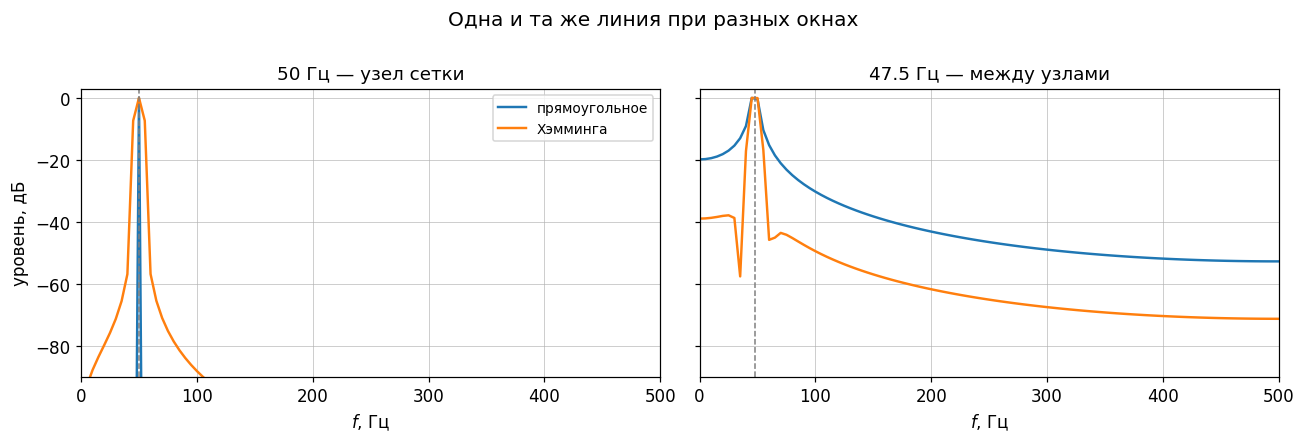

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for axis, f0 in zip(axes, (50.0, 47.5)):
    for name, window in WINDOWS.items():
        axis.plot(freqs, tone_spectrum_db(f0, window), lw=1.6, label=name)
    axis.axvline(f0, color="0.5", ls="--", lw=1)
    axis.set(xlim=(0, FS / 2), ylim=(-90, 3), xlabel="$f$, Гц",
             title="%g Гц — %s" % (f0, "узел сетки" if abs(f0 / DF - round(f0 / DF)) < 1e-9
                                   else "между узлами"))
axes[0].set(ylabel="уровень, дБ")
axes[0].legend(loc="upper right", fontsize=9)
fig.suptitle("Одна и та же линия при разных окнах", y=1.0)
fig.tight_layout()
plt.show()

## Ячейка 4 · Почему это важно именно для ЭМГ

Наводка от сети — ровно тот случай. Она сидит на 50 Гц, но частота в розетке
слегка плавает, а длину окна мы выбираем не под неё. Значит в реальной записи
50 Гц почти никогда не попадает в узел сетки: линия размазывается и залезает
в полезную полосу 20–450 Гц.

Посмотрим на это на самой ЭМГ. Заодно измерим **медианную частоту** MDF —
признак, которым в E2 и E6 оценивают состояние мышцы.

Одна тонкость, которая сразу видна на картинке. Наводка — это **линия**: вся
её мощность сидит в одном узле сетки. ЭМГ — широкополосный процесс: та же
мощность размазана по сотням герц, и на каждый узел приходится крохотная
доля. Поэтому в спектре линия торчит гораздо заметнее, чем слышна в сигнале,
а на глаз во времени наводку при таком уровне почти не отличить от мышцы.
Насколько именно линия возвышается над фоном, зависит от $\Delta f$: сделаешь
окно длиннее — фон на узел упадёт, а линия останется, и она станет ещё выше.

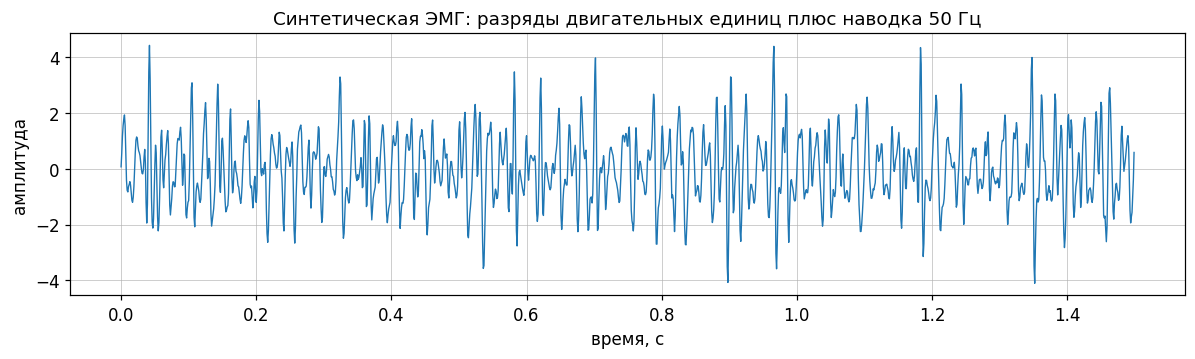

In [5]:
N = 4096
MAINS_LEVEL = 1.0

emg = synth_emg(N, FS, seed=20260826)
signal = emg + MAINS_LEVEL * mains_hum(N, FS)

fig, ax = plt.subplots(figsize=(11, 3.4))
ax.plot(np.arange(1500) / FS, signal[:1500], lw=0.9, color="tab:blue")
ax.set(xlabel="время, с", ylabel="амплитуда",
       title="Синтетическая ЭМГ: разряды двигательных единиц плюс наводка 50 Гц")
fig.tight_layout()
plt.show()

## Ячейка 5 · Одно окно против усреднения

`scipy.signal.welch` делает ровно то, что описано в теории: режет сигнал на
перекрывающиеся окна, считает периодограмму каждого и усредняет. Поставив
`nperseg = len(x)`, мы получаем ту самую «одну периодограмму» без всякого
усреднения — с ней и сравним.

шаг сетки Δf = 3.91 Гц
MDF по одному окну  :  54.7 Гц
MDF по оценке Уэлча :  70.3 Гц


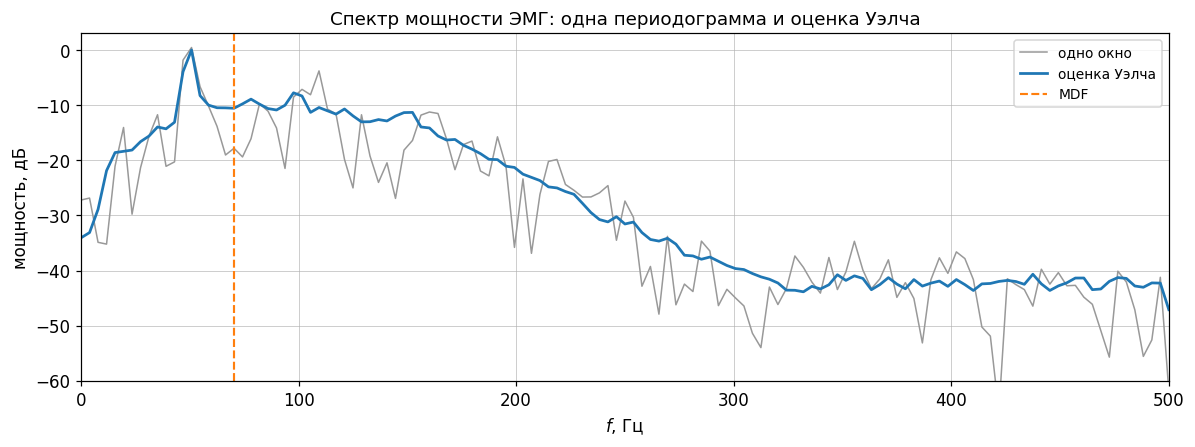

In [6]:
from scipy.signal import welch

L_EMG = 256

f_one, p_one = welch(signal[:L_EMG], fs=FS, nperseg=L_EMG, window="hamming")
f_avg, p_avg = welch(signal, fs=FS, nperseg=L_EMG, noverlap=L_EMG // 2,
                     window="hamming")

print("шаг сетки Δf = %.2f Гц" % (FS / L_EMG))
print("MDF по одному окну  : %5.1f Гц" % median_frequency(f_one, p_one))
print("MDF по оценке Уэлча : %5.1f Гц" % median_frequency(f_avg, p_avg))

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(f_one, 10 * np.log10(p_one / p_avg.max() + 1e-15),
        color="0.6", lw=1, label="одно окно")
ax.plot(f_avg, 10 * np.log10(p_avg / p_avg.max() + 1e-15),
        color="tab:blue", lw=1.8, label="оценка Уэлча")
ax.axvline(median_frequency(f_avg, p_avg), color="tab:orange", ls="--", lw=1.4,
           label="MDF")
ax.set(xlim=(0, FS / 2), ylim=(-60, 3), xlabel="$f$, Гц", ylabel="мощность, дБ",
       title="Спектр мощности ЭМГ: одна периодограмма и оценка Уэлча")
ax.legend(loc="upper right", fontsize=9)
fig.tight_layout()
plt.show()

Бледная ломаная скачет на десятки децибел от бина к бину — это не структура
сигнала, это разброс оценки. Синяя кривая построена по тем же данным, просто
усреднена, и по ней уже видно и полосу мышцы, и линию наводки.

## Ячейка 6 · Насколько усреднение помогает

Разброс усреднённой оценки падает примерно как $1/\sqrt{K}$. Проверим это
прямо: посчитаем периодограммы отдельных окон, усредним первые $K$ из них и
посмотрим на относительный разброс внутри рабочей полосы.

Заодно посчитаем MDF два раза: по чистой ЭМГ и по той же ЭМГ с наводкой.
Разница между двумя столбцами — не про усреднение, а про то, что мы вообще
измеряем.

In [7]:
STEP = L_EMG // 2
window_h = np.hamming(L_EMG)
scale = FS * (window_h ** 2).sum()
freqs_seg = np.fft.rfftfreq(L_EMG, d=1 / FS)
band = (freqs_seg >= 20) & (freqs_seg <= 450)


def periodograms(x):
    """Периодограммы всех окон длиной L_EMG с перекрытием наполовину."""
    out = []
    start = 0
    while start + L_EMG <= len(x):
        power = np.abs(np.fft.rfft(x[start:start + L_EMG] * window_h)) ** 2 / scale
        power[1:-1] *= 2
        out.append(power)
        start += STEP
    return np.array(out)


clean = periodograms(emg)            # ЭМГ без наводки
dirty = periodograms(signal)         # та же ЭМГ плюс 50 Гц

print("окон всего: %d" % len(clean))
print(" K   разброс оценки   MDF чистой   MDF с наводкой")
for K in (1, 2, 4, 8, 16, len(clean)):
    chunk = clean[:K]
    average = chunk.mean(axis=0)
    if K > 1:
        spread = 100 * np.mean(chunk[:, band].std(axis=0, ddof=1)
                               / average[band]) / np.sqrt(K)
    else:
        spread = 100.0
    print("%3d   %10.1f %%   %8.1f Гц   %11.1f Гц"
          % (K, spread, median_frequency(freqs_seg, average),
             median_frequency(freqs_seg, dirty[:K].mean(axis=0))))

окон всего: 31
 K   разброс оценки   MDF чистой   MDF с наводкой
  1        100.0 %      109.4 Гц          54.7 Гц
  2         55.5 %       89.8 Гц          66.4 Гц
  4         43.9 %       93.8 Гц          58.6 Гц
  8         31.6 %       93.8 Гц          74.2 Гц
 16         23.5 %       93.8 Гц          74.2 Гц
 31         17.2 %       93.8 Гц          70.3 Гц


Разброс идёт вниз примерно во столько раз, во сколько растёт $\sqrt{K}$ —
ровно как обещает теория. Столбец «MDF чистой» ведёт себя так же: от $K = 4$
он замирает на одном значении, потому что оценка перестала прыгать.

А столбец «MDF с наводкой» не замирает ни при каком $K$ — и это не недостаток
усреднения. Усреднение убирает **случайный** разброс; наводка не случайна, она
каждый раз добавляет ту же самую мощность в тот же узел сетки. Половина
мощности набирается уже почти на линии 50 Гц, MDF садится на её плечо, и там
крохотное изменение формы спектра двигает ответ на десяток герц.

Вывод, который стоит запомнить: **улучшать оценку спектра бессмысленно, пока в
сигнале сидит помеха, которой там быть не должно.** Сначала фильтр, потом
оценка. Фильтром займётся следующая работа.

Плата за усреднение видна из той же таблицы: сигнал конечной длины, и чем
больше окон мы хотим, тем короче каждое — а короткое окно означает грубый шаг
$\Delta f$ и, значит, хуже различимые линии.

## Задания

1. Поставь частоту тона из своего варианта и запиши, сколько периодов
   помещается в окно и до какого уровня падают боковые лепестки для обоих окон.
2. Повтори ячейку 5 со своими значениями `MAINS_LEVEL` и `L_EMG`. На сколько
   герц уезжает MDF, если убрать наводку в ноль?
3. По таблице из ячейки 6 найди минимальное $K$, при котором MDF чистой ЭМГ
   перестаёт меняться больше чем на 2 Гц.
4. Уменьшай `MAINS_LEVEL` и следи, при каком уровне второй столбец MDF
   начинает сходиться к первому. Это и есть граница, за которой наводка
   перестаёт портить признак.
5. Замени окно Хэмминга на прямоугольное (`window="boxcar"`) при большой
   наводке и посмотри, что происходит с юбкой линии 50 Гц.